Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f07c6770ae0>
  [1] SingleMuonAnalysis -> Analysis builder=<function run_analysis at 0x7f07c5c87420>
  [2] PlottingMuonAnalysis -> Plotting builder=analysis:plot_results
Edges:
  Fileset -> SingleMuonAnalysis
  SingleMuonAnalysis -> PlottingMuonAnalysis
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f07c6770ae0> and user parameters {'to_print': '\nTEST:\nparameter testing...\nSUCCESS!\n'}
Extracted from cache: .cache/Fileset/396cfc606caca284dbc25984b2b9ec38f90f85e98b42c872d327b5722e43a234
  -> materialized at .cache/Fileset/396cfc606caca284dbc25984b2b9ec38f90f85e98b42c872d327b5722e43a234
Executing step 'SingleMuonAnalysis' of type 'Analysis' with the user code <function run_analysis at 0x7f07c5c87420> and user parameters None
Extracted from cache: .cache/Chunking/c7d4db80e19846c781ca74653656a2abf8234cfd85fb15afa17dac0a8afa0864

Split strategy applied, starting independen

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 144, in open
    file = ReadOnlyFile(
           ^^^^^^

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: .cache/ChunkAnalysis/828b42b4a82b6117f8ef44a4fc1095a8da17eb420841eb85c5550765acd2b9d6
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json


Output()

...

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_5.json


Output()

Output()

Successfully processed!
  -> materialized at .cache/Analysis/bc7195b0bfa3a0d62f42006867abbbe98098f44de98121c0c7d1e7e8a04f0a12
Executing step 'PlottingMuonAnalysis' of type 'Plotting' with the user code analysis:plot_results and user parameters None
Result keys: ['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result']
n_chunks_ok: 5 / 6
  -> materialized at .cache/Plotting/33240c6c5fac7068d2acef7aff7aa13d8550f8dda3dff8e206a6415a71cd917a

=== Run Summary ===
  ✓  Fileset                        Fileset
  !  SingleMuonAnalysis             Analysis             5/6 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('XRootD error: [FATAL] Invalid address'))
  ✓  PlottingMuonAnalysis           Plotting



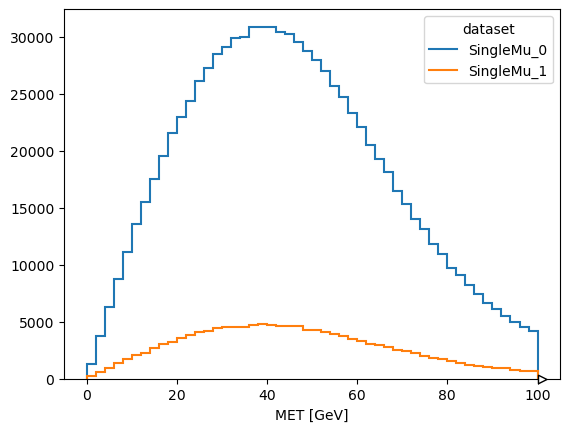

In [2]:
from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, render, CustomArtifact, FacilityConfig
from analysis import get_fileset, run_analysis, plot_results, custom_function_remove_last_file

step_fileset = Step(
							        name="Fileset",
							        step_type = Fileset,
							        builder = get_fileset,
                                    builder_params = {"to_print": "\nTEST:\nparameter testing...\nSUCCESS!\n"}
							    )

step_custom_filtering = Step(
						        name="FilesetFiltering",
						        step_type = CustomArtifact,
						        builder = custom_function_remove_last_file,
						    )
							    
step_analysis = Step(
						        name="SingleMuonAnalysis",
						        step_type = Analysis,
						        builder = run_analysis,
						    )

step_plotting = Step(
										name="PlottingMuonAnalysis",
										step_type = Plotting,
										builder = "analysis:plot_results"
								)		
								   
workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])


config = RunConfig(
    strategy="by_dataset",
    percentage=10,
    chunk_fraction=0.6,
    facility=FacilityConfig(name="coffea-casa"),
    executor_config=ExecutorConfig(executor_type="FuturesExecutor"),
)


# config = RunConfig(
#     strategy="by_dataset",
#     percentage=10,
#     chunk_fraction=0.2,
#     facility=FacilityConfig(name="coffea-casa"),
#     executor_config=ExecutorConfig(executor_type="DaskExecutor"),
# )


result = render(workflow, config)
